# 03 — Readmission Prediction Model
## MedIQ — Hospital Patient Analytics & Readmission Predictor
**Goal:** Build an XGBoost classifier to predict 30-day hospital readmission, handle class imbalance with SMOTE, evaluate with clinical metrics, and explain predictions using SHAP.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import joblib

os.makedirs('../models', exist_ok=True)

# Load clean data
df = pd.read_csv('../data/processed/mediq_clean.csv')

print(f"✅ Data loaded: {df.shape}")
print(f"   High risk patients : {df['readmitted_binary'].sum():,}")
print(f"   Low risk patients  : {(df['readmitted_binary']==0).sum():,}")
print(f"   Class imbalance    : 1:{(df['readmitted_binary']==0).sum()//df['readmitted_binary'].sum()}")

✅ Data loaded: (101745, 45)
   High risk patients : 11,352
   Low risk patients  : 90,393
   Class imbalance    : 1:7


In [2]:
# Select features for model
feature_cols = [
    # Numerical
    'age_numeric', 'time_in_hospital', 'num_lab_procedures',
    'num_procedures', 'num_medications', 'number_outpatient',
    'number_emergency', 'number_inpatient', 'number_diagnoses',
    'num_meds_changed', 'num_meds_active', 'utilization_score',
    # Categorical
    'race', 'gender', 'admission_type_id', 'discharge_disposition_id',
    'admission_source_id', 'max_glu_serum', 'A1Cresult',
    'insulin', 'change', 'diabetesMed', 'diag_1_category'
]

df_model = df[feature_cols + ['readmitted_binary']].copy()

# Encode categorical columns
cat_cols = ['race', 'gender', 'max_glu_serum', 'A1Cresult',
            'insulin', 'change', 'diabetesMed', 'diag_1_category']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

# Save encoders for Flask app
joblib.dump(le_dict, '../models/label_encoders.pkl')

print(f"✅ Features prepared")
print(f"   Total features : {len(feature_cols)}")
print(f"   Numerical      : {len([c for c in feature_cols if c not in cat_cols])}")
print(f"   Categorical    : {len(cat_cols)}")
print(f"\nFeature list:")
for f in feature_cols:
    print(f"   {f}")

✅ Features prepared
   Total features : 23
   Numerical      : 15
   Categorical    : 8

Feature list:
   age_numeric
   time_in_hospital
   num_lab_procedures
   num_procedures
   num_medications
   number_outpatient
   number_emergency
   number_inpatient
   number_diagnoses
   num_meds_changed
   num_meds_active
   utilization_score
   race
   gender
   admission_type_id
   discharge_disposition_id
   admission_source_id
   max_glu_serum
   A1Cresult
   insulin
   change
   diabetesMed
   diag_1_category


In [3]:
# Split features and target
X = df_model[feature_cols]
y = df_model['readmitted_binary']

# Train test split — stratified to maintain class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")
print(f"\nBefore SMOTE:")
print(f"   High risk : {y_train.sum():,}")
print(f"   Low risk  : {(y_train==0).sum():,}")

# Apply SMOTE to training data only — never on test data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"   High risk : {y_train_sm.sum():,}")
print(f"   Low risk  : {(y_train_sm==0).sum():,}")
print(f"   Total     : {len(X_train_sm):,}")
print(f"\n✅ Class balance achieved — ready for training")

Train size : 81,396
Test size  : 20,349

Before SMOTE:
   High risk : 9,082
   Low risk  : 72,314

After SMOTE:
   High risk : 72,314
   Low risk  : 72,314
   Total     : 144,628

✅ Class balance achieved — ready for training


In [4]:
# Train XGBoost — best model for tabular clinical data
print("Training XGBoost model...")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predictions
y_pred       = xgb.predict(X_test)
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

# Save model
joblib.dump(xgb, '../models/mediq_model.pkl')
joblib.dump(feature_cols, '../models/feature_cols.pkl')

print(f"✅ XGBoost model trained and saved")
print(f"\n=== MODEL PERFORMANCE ===")
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Low Risk', 'High Risk']))

Training XGBoost model...
✅ XGBoost model trained and saved

=== MODEL PERFORMANCE ===
ROC-AUC Score : 0.6099

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.90      0.94      0.92     18079
   High Risk       0.22      0.13      0.17      2270

    accuracy                           0.85     20349
   macro avg       0.56      0.54      0.54     20349
weighted avg       0.82      0.85      0.83     20349



In [5]:
from sklearn.metrics import f1_score

# Find optimal threshold for clinical use
# In healthcare — catching high risk patients (recall) matters more than precision
thresholds = np.arange(0.1, 0.9, 0.05)
best_threshold = 0.5
best_f1 = 0

results = []
for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh, pos_label=1)
    recall = (y_pred_thresh[y_test==1]).mean()
    precision = y_pred_thresh[y_test==1].sum() / y_pred_thresh.sum() if y_pred_thresh.sum() > 0 else 0
    results.append({'threshold': thresh, 'f1': f1, 
                   'recall': recall, 'precision': precision})
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

df_thresh = pd.DataFrame(results)

print(f"✅ Threshold optimization complete")
print(f"\nOptimal threshold: {best_threshold:.2f}")
print(f"Best F1 score    : {best_f1:.4f}")
print(f"\nPerformance at optimal threshold:")
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_optimal,
      target_names=['Low Risk','High Risk']))

# Save optimal threshold
joblib.dump(best_threshold, '../models/optimal_threshold.pkl')
print(f"✅ Optimal threshold saved: {best_threshold:.2f}")

✅ Threshold optimization complete

Optimal threshold: 0.25
Best F1 score    : 0.2313

Performance at optimal threshold:
              precision    recall  f1-score   support

    Low Risk       0.91      0.67      0.77     18079
   High Risk       0.15      0.48      0.23      2270

    accuracy                           0.65     20349
   macro avg       0.53      0.57      0.50     20349
weighted avg       0.83      0.65      0.71     20349

✅ Optimal threshold saved: 0.25


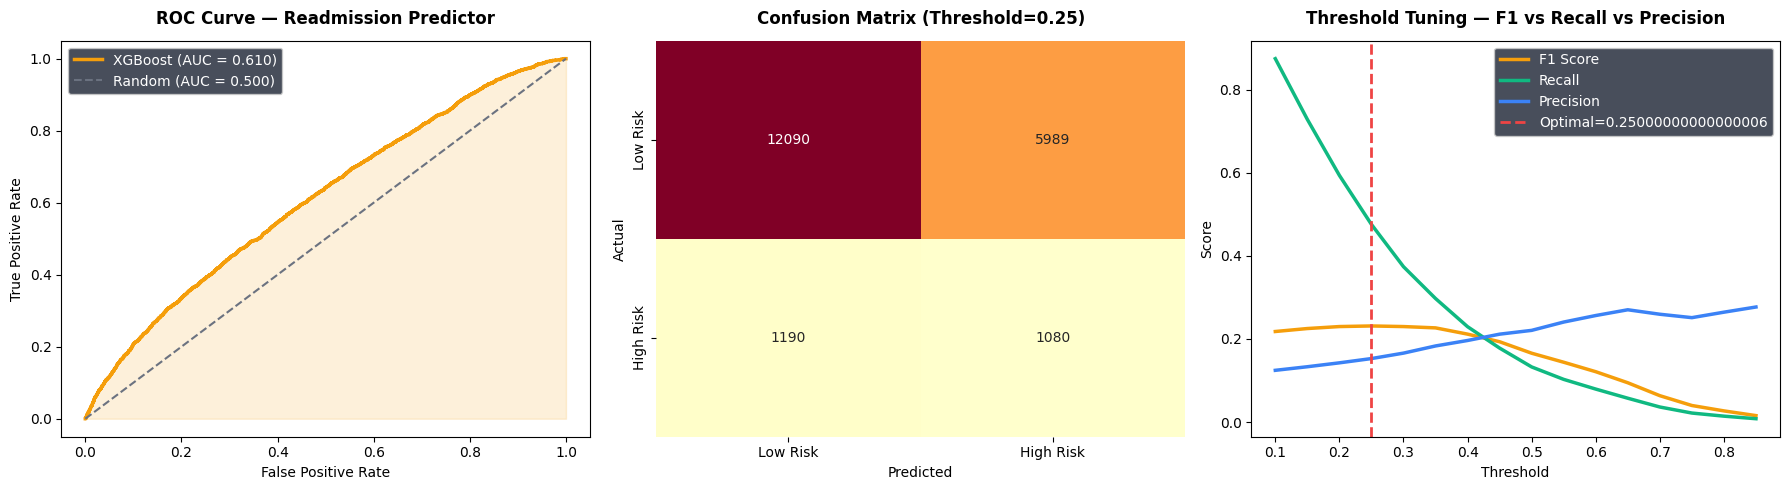

✅ Chart saved → screenshots/05_model_performance.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plt.rcParams['axes.facecolor'] = '#1A2232'
plt.rcParams['figure.facecolor'] = '#0A0E1A'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

# Chart 1 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#F59E0B', linewidth=2.5,
             label=f'XGBoost (AUC = {auc:.3f})')
axes[0].plot([0,1],[0,1], color='#6B7280', linestyle='--',
             linewidth=1.5, label='Random (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='#F59E0B')
axes[0].set_title('ROC Curve — Readmission Predictor',
                  fontweight='bold', pad=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Chart 2 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Low Risk','High Risk'],
            yticklabels=['Low Risk','High Risk'],
            ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix (Threshold=0.25)',
                  fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Chart 3 — Threshold vs F1/Recall
axes[2].plot(df_thresh['threshold'], df_thresh['f1'],
             color='#F59E0B', linewidth=2.5, label='F1 Score')
axes[2].plot(df_thresh['threshold'], df_thresh['recall'],
             color='#10B981', linewidth=2.5, label='Recall')
axes[2].plot(df_thresh['threshold'], df_thresh['precision'],
             color='#3B82F6', linewidth=2.5, label='Precision')
axes[2].axvline(x=best_threshold, color='#EF4444',
                linestyle='--', linewidth=2, label=f'Optimal={best_threshold}')
axes[2].set_title('Threshold Tuning — F1 vs Recall vs Precision',
                  fontweight='bold', pad=12)
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Score')
axes[2].legend()

plt.tight_layout()
plt.savefig('../screenshots/05_model_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/05_model_performance.png")

Calculating SHAP values — this takes 2-3 minutes...


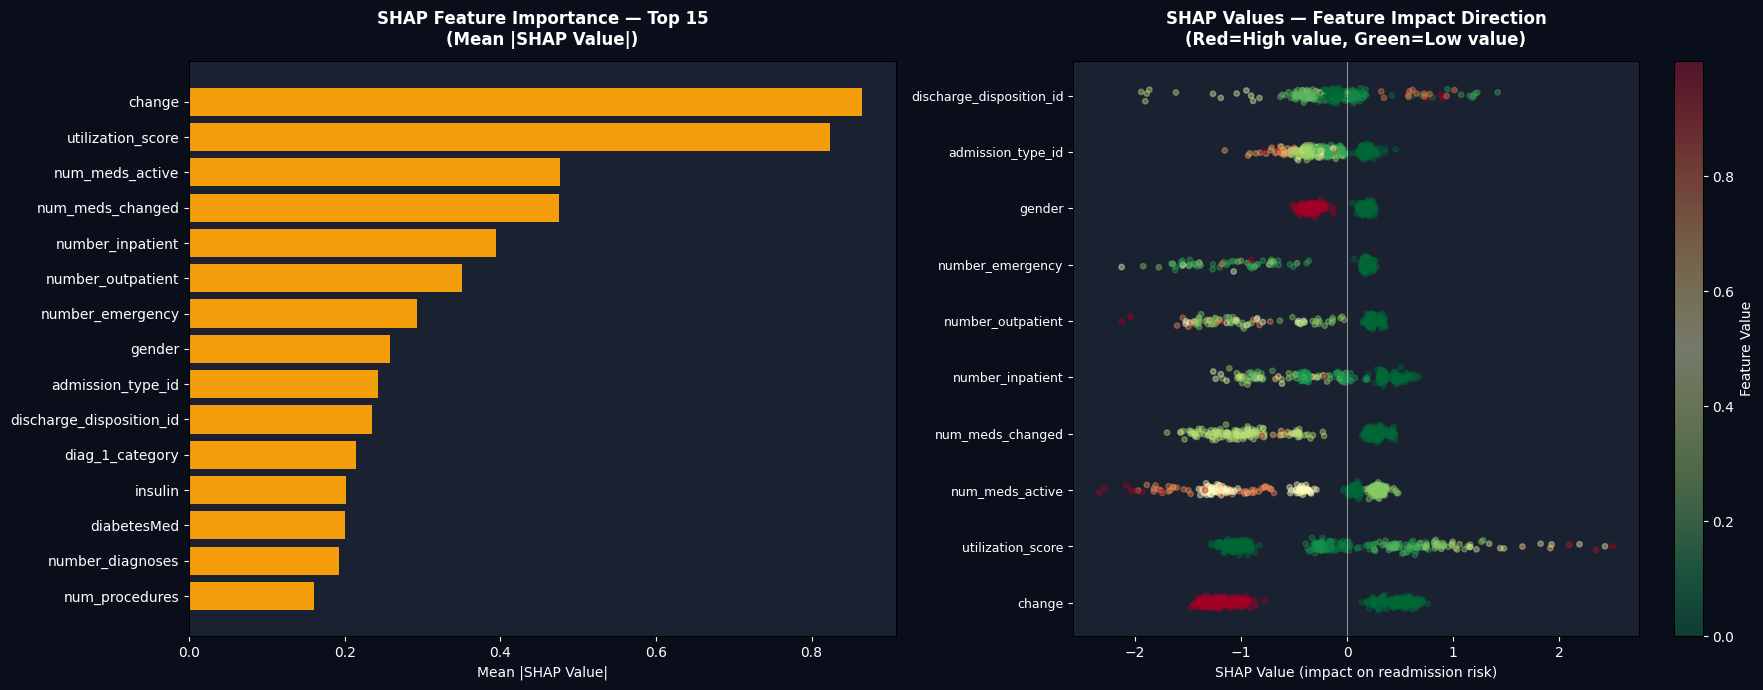

✅ SHAP chart saved → screenshots/06_shap_importance.png


In [7]:
print("Calculating SHAP values — this takes 2-3 minutes...")

# Use a sample for SHAP — full dataset is too slow
X_sample = X_test.sample(n=500, random_state=42)

# SHAP explainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

# Plot 1 — Feature importance (SHAP)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.rcParams['axes.facecolor'] = '#1A2232'
plt.rcParams['figure.facecolor'] = '#0A0E1A'

# Mean absolute SHAP values
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=True).tail(15)

axes[0].barh(shap_importance['feature'],
             shap_importance['importance'],
             color='#F59E0B')
axes[0].set_title('SHAP Feature Importance — Top 15\n(Mean |SHAP Value|)',
                  fontweight='bold', pad=12)
axes[0].set_xlabel('Mean |SHAP Value|')

# Plot 2 — SHAP summary for top 10 features
top10_idx = shap_importance.tail(10).index.tolist()
top10_features = shap_importance.tail(10)['feature'].tolist()
shap_top10 = shap_values[:, [feature_cols.index(f) for f in top10_features]]
X_sample_top10 = X_sample[top10_features]

# Manual dot plot
for i, feat in enumerate(reversed(top10_features)):
    feat_idx = feature_cols.index(feat)
    sv = shap_values[:, feat_idx]
    fv = X_sample[feat].values
    fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-8)
    scatter = axes[1].scatter(sv,
                [i + np.random.normal(0, 0.05) for _ in sv],
                c=fv_norm, cmap='RdYlGn_r',
                alpha=0.4, s=15)

axes[1].set_yticks(range(len(top10_features)))
axes[1].set_yticklabels(reversed(top10_features), fontsize=9)
axes[1].axvline(x=0, color='white', linewidth=0.8, alpha=0.5)
axes[1].set_title('SHAP Values — Feature Impact Direction\n(Red=High value, Green=Low value)',
                  fontweight='bold', pad=12)
axes[1].set_xlabel('SHAP Value (impact on readmission risk)')
plt.colorbar(scatter, ax=axes[1], label='Feature Value')

plt.tight_layout()
plt.savefig('../screenshots/06_shap_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP chart saved → screenshots/06_shap_importance.png")

In [8]:
# Save feature importance for Power BI
shap_df = pd.DataFrame({
    'feature': feature_cols,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

shap_df.to_csv('../exports/shap_importance.csv', index=False)

# Save test predictions for Power BI
pred_df = X_test.copy()
pred_df['actual'] = y_test.values
pred_df['predicted'] = y_pred_optimal
pred_df['risk_probability'] = y_pred_proba
pred_df['risk_category'] = pd.cut(
    pred_df['risk_probability'],
    bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
)
pred_df.to_csv('../exports/predictions.csv', index=False)

print("✅ Model artifacts saved")
print(f"\n=== MEDIQ MODEL SUMMARY ===")
print(f"Algorithm      : XGBoost Classifier")
print(f"Features       : {len(feature_cols)}")
print(f"Training size  : {len(X_train_sm):,} (after SMOTE)")
print(f"Test size      : {len(X_test):,}")
print(f"ROC-AUC        : {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Recall (High Risk): {(y_pred_optimal[y_test==1]).mean()*100:.1f}%")
print(f"\nTop 5 readmission predictors:")
for i, row in shap_df.head(5).iterrows():
    print(f"   {row['feature']:<25} SHAP: {row['shap_importance']:.4f}")
print(f"\nModels saved → models/")
print(f"   mediq_model.pkl")
print(f"   label_encoders.pkl")
print(f"   feature_cols.pkl")
print(f"   optimal_threshold.pkl")
print(f"\nNext → 04_dashboard_prep.ipynb")

✅ Model artifacts saved

=== MEDIQ MODEL SUMMARY ===
Algorithm      : XGBoost Classifier
Features       : 23
Training size  : 144,628 (after SMOTE)
Test size      : 20,349
ROC-AUC        : 0.6099
Optimal threshold: 0.25
Recall (High Risk): 47.6%

Top 5 readmission predictors:
   change                    SHAP: 0.8651
   utilization_score         SHAP: 0.8242
   num_meds_active           SHAP: 0.4769
   num_meds_changed          SHAP: 0.4755
   number_inpatient          SHAP: 0.3947

Models saved → models/
   mediq_model.pkl
   label_encoders.pkl
   feature_cols.pkl
   optimal_threshold.pkl

Next → 04_dashboard_prep.ipynb
